# Data Exploration

1. ✅ Data Exploration        ← já fizemos
2. 🔄 Data Preprocessing     ← próximo passo
3.    Corpus Split            ← train/validation
4.    Feature Engineering     ← BoW, Word2Vec, Transformers
5.    Classification Models   ← ML clássico + Transformers
6.    Avaliação & Análise     ← métricas e conclusões
7.    Predições no test.csv   ← ficheiro pred_xx.csv final

In [3]:
!pip install nltk


  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)

   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   ---------------------------------------- 3/3 [nltk]



In [4]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

...

Ellipsis

In [5]:
STOP = set(stopwords.words('english'))

# Palette consistente com as 3 classes
CLASS_COLORS = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
CLASS_NAMES  = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}

In [6]:
df = pd.read_csv('train.csv')  

In [7]:
print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'Tipos:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(10)

Shape: (9543, 2)
Colunas: ['text', 'label']
Tipos:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


## 1. Distribuição das Classes

importante para ver se as classes estao desbalenceadas porque se tiverem é para balenciar 

Se por exemplo 60% dos tweets forem Neutral, os teus modelos vão ter tendência a classificar tudo como Neutral.

=== Contagem por classe ===
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


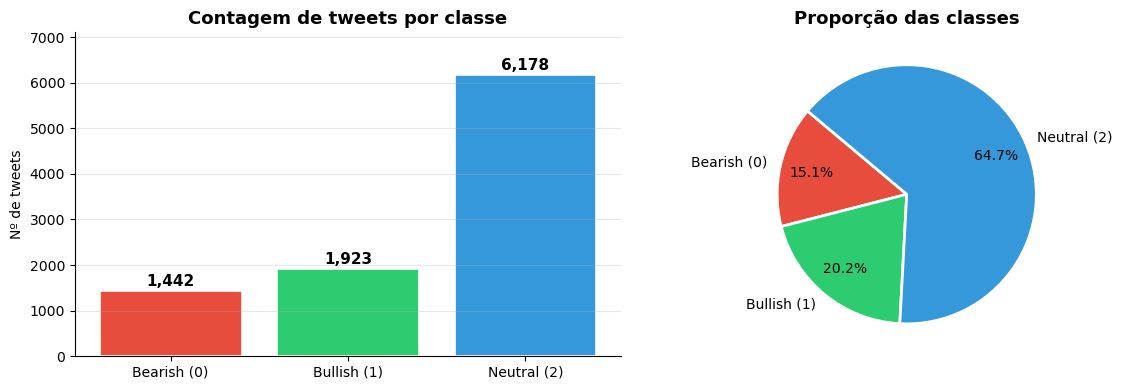


⚠️  Baseline (majority class): 64.7% — qualquer modelo deve superar este valor.


In [8]:
# ── Distribuição das classes ──────────────────────────────────────────────────
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

print('=== Contagem por classe ===')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Contagem de tweets por classe', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nº de tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

# Majority class baseline
majority_acc = label_counts.max() / len(df) * 100
print(f'\n⚠️  Baseline (majority class): {majority_acc:.1f}% — qualquer modelo deve superar este valor.')

## 2. Análise do Comprimento dos Tweets

=== Estatísticas de comprimento (chars / palavras) ===
       n_chars  n_words
count   9543.0   9543.0
mean      85.8     12.2
std       35.1      4.7
min        2.0      1.0
25%       58.0      9.0
50%       79.0     11.0
75%      120.0     15.0
max      190.0     32.0


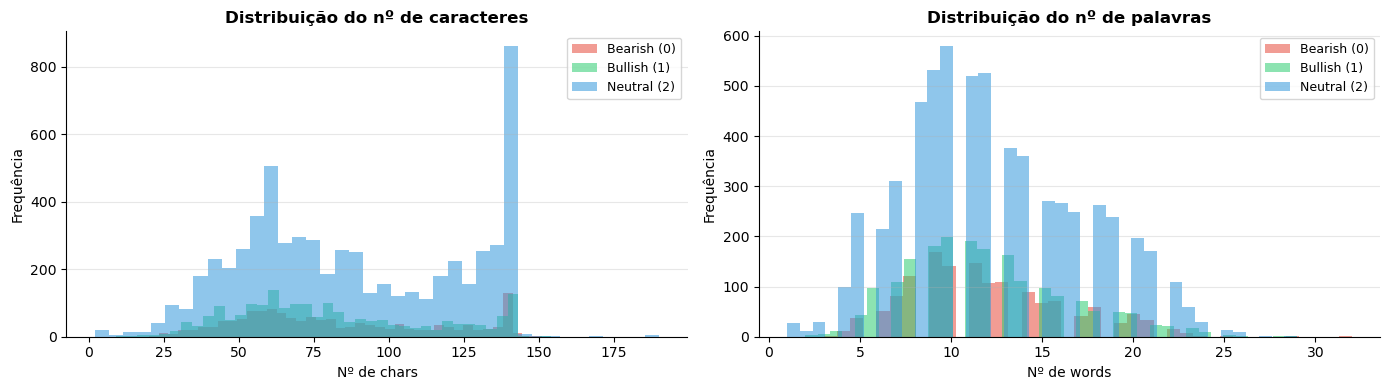


=== Comprimento médio por classe ===
             n_chars  n_words
label                        
Bearish (0)     83.3     12.0
Bullish (1)     80.4     11.9
Neutral (2)     88.1     12.3


In [9]:
# ── Comprimento dos tweets ────────────────────────────────────────────────────
df['n_chars']  = df['text'].str.len()
df['n_words']  = df['text'].str.split().str.len()
df['n_tokens'] = df['text'].apply(lambda x: len(word_tokenize(str(x))))

print('=== Estatísticas de comprimento (chars / palavras) ===')
print(df[['n_chars', 'n_words']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for metric, ax, title in [
    ('n_chars', axes[0], 'Distribuição do nº de caracteres'),
    ('n_words', axes[1], 'Distribuição do nº de palavras')
]:
    for lbl in [0, 1, 2]:
        subset = df[df['label'] == lbl][metric]
        ax.hist(subset, bins=40, alpha=0.55,
                color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric.replace('n_', 'Nº de '))
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig_length_distribution.png', bbox_inches='tight')
plt.show()

# Por classe
print('\n=== Comprimento médio por classe ===')
print(df.groupby('label')[['n_chars', 'n_words']].mean().round(1).rename(index=CLASS_NAMES))

## 3. Vocabulário Global

In [10]:
# ── Vocabulário ───────────────────────────────────────────────────────────────
def tokenize_clean(text):
    """Tokeniza, lowercase, remove pontuação e stopwords."""
    text  = str(text).lower()
    text  = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text  = re.sub(r'@\w+|#\w+', '', text)            # @mentions e #hashtags
    text  = re.sub(r'[^a-z\s]', ' ', text)            # Apenas letras
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]

all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_clean(txt))

vocab      = set(all_tokens)
freq       = Counter(all_tokens)
top50      = freq.most_common(50)

print(f'Total de tokens (sem stopwords): {len(all_tokens):,}')
print(f'Vocabulário único (palavras distintas): {len(vocab):,}')
print(f'\n🔝 Top 20 palavras mais frequentes:')
for word, cnt in top50[:20]:
    print(f'   {word:<20} {cnt:>5}')

Total de tokens (sem stopwords): 73,385
Vocabulário único (palavras distintas): 14,016

🔝 Top 20 palavras mais frequentes:
   stock                  611
   new                    417
   results                374
   market                 359
   says                   349
   earnings               346
   inc                    316
   china                  311
   dividend               292
   price                  290
   stocks                 279
   year                   274
   reports                259
   trade                  252
   buy                    237
   deal                   234
   oil                    233
   shares                 223
   revenue                218
   beats                  209


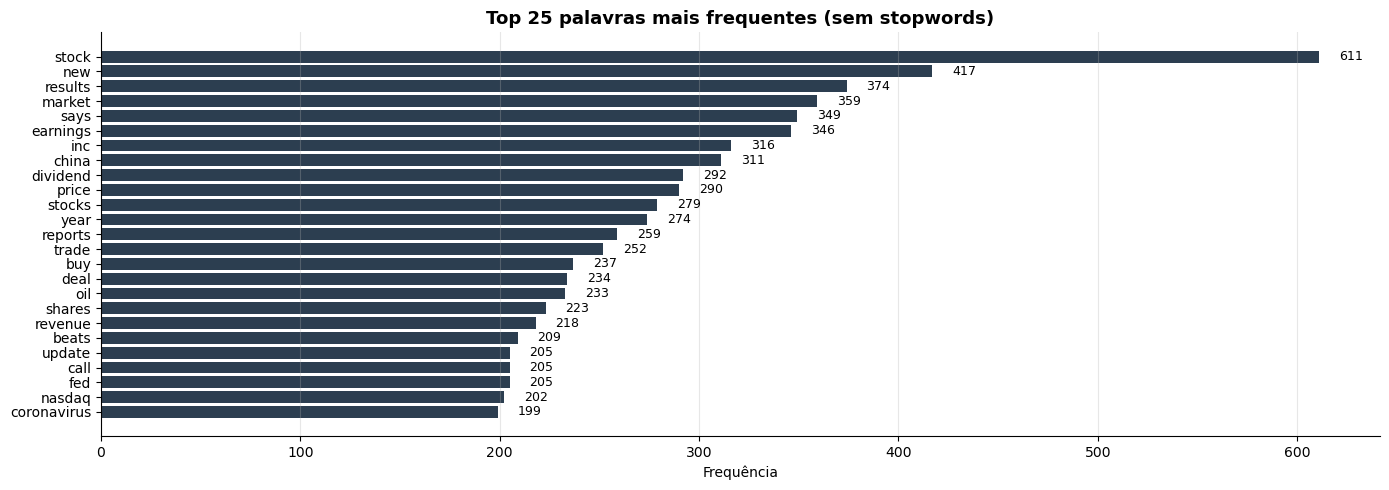

In [11]:
# ── Bar chart top 25 palavras ─────────────────────────────────────────────────
top25_words, top25_counts = zip(*top50[:25])

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_title('Top 25 palavras mais frequentes (sem stopwords)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequência')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig_top_words.png', bbox_inches='tight')
plt.show()

## 5. Top Palavras Específicas por Classe

Aqui identificamos palavras que são **distintivas** de cada classe — frequentes numa classe mas raras nas outras.

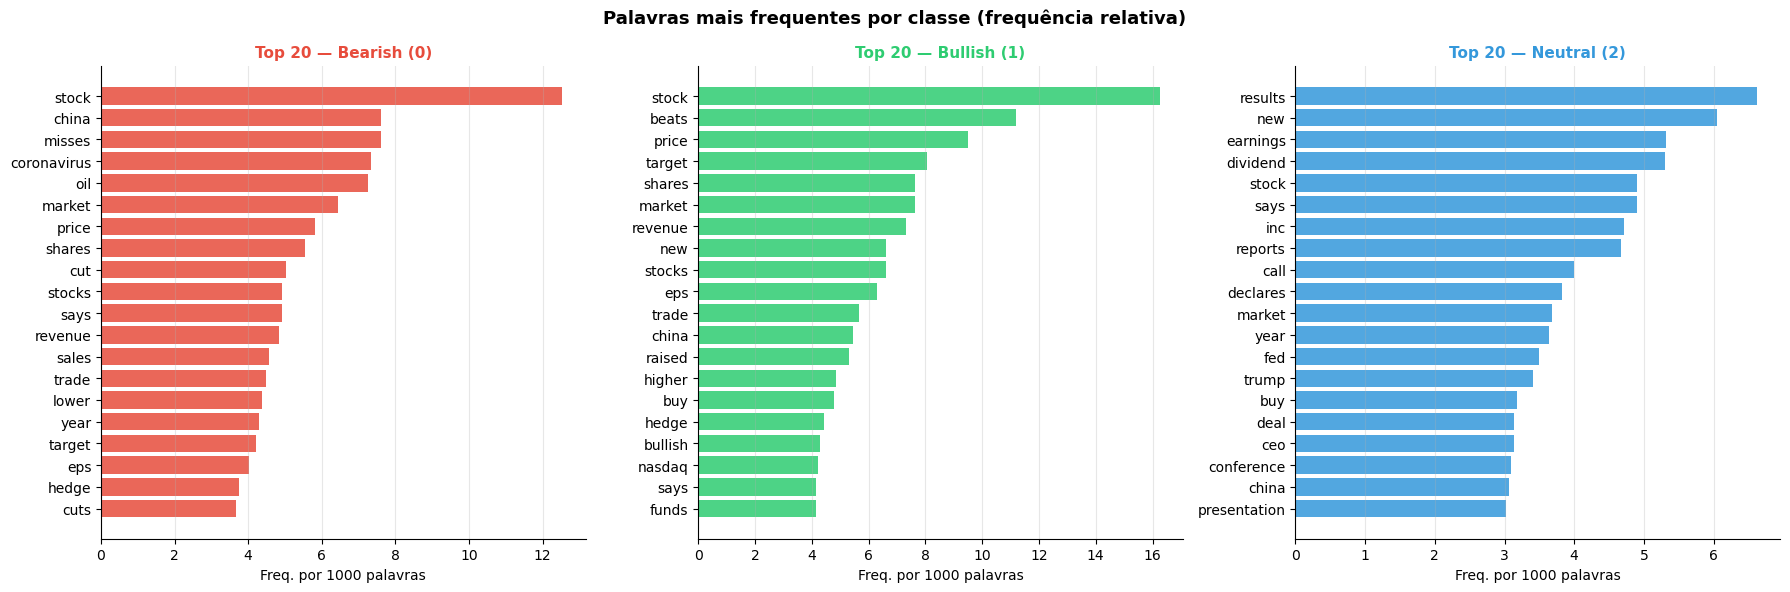

In [12]:
# ── Top palavras por classe (frequência relativa) ─────────────────────────────
tokens_per_class = {}
for lbl in [0, 1, 2]:
    toks = []
    for txt in df[df['label'] == lbl]['text']:
        toks.extend(tokenize_clean(txt))
    tokens_per_class[lbl] = Counter(toks)

total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    # Frequência relativa (por 1000 palavras)
    rel_freq = {w: cnt / total_per_class[lbl] * 1000
                for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top_words = sorted(rel_freq, key=rel_freq.get, reverse=True)[:20]
    
    ax.barh(list(reversed(top_words)),
            [rel_freq[w] for w in reversed(top_words)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. por 1000 palavras')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Palavras mais frequentes por classe (frequência relativa)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_top_words_per_class.png', bbox_inches='tight')
plt.show()

## 6. Análise de Características Especiais dos Tweets

In [13]:
# ── Hashtags, @mentions, URLs, números ───────────────────────────────────────
df['n_hashtags']  = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['n_mentions']  = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['n_urls']      = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['n_numbers']   = df['text'].apply(lambda x: len(re.findall(r'\b\d+\.?\d*%?\b', str(x))))
df['has_cashtag'] = df['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', str(x))))  # e.g. $AAPL

print('=== Presença média por tweet ===')
for feat in ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']:
    print(f'  {feat:<15}: {df[feat].mean():.2f} (max: {df[feat].max()})')
print(f'  Tweets com cashtag ($TICKER): {df["has_cashtag"].sum():,} ({df["has_cashtag"].mean()*100:.1f}%)')

# Por classe
print('\n=== Média por classe ===')
feat_by_class = df.groupby('label')[['n_hashtags','n_mentions','n_urls','n_numbers']].mean().round(2)
feat_by_class.index = [CLASS_NAMES[i] for i in feat_by_class.index]
print(feat_by_class)

=== Presença média por tweet ===
  n_hashtags     : 0.23 (max: 7)
  n_mentions     : 0.04 (max: 8)
  n_urls         : 0.53 (max: 3)
  n_numbers      : 0.50 (max: 12)
  Tweets com cashtag ($TICKER): 1,429 (15.0%)

=== Média por classe ===
             n_hashtags  n_mentions  n_urls  n_numbers
Bearish (0)        0.17        0.02    0.51       0.53
Bullish (1)        0.16        0.02    0.44       0.74
Neutral (2)        0.27        0.05    0.57       0.42


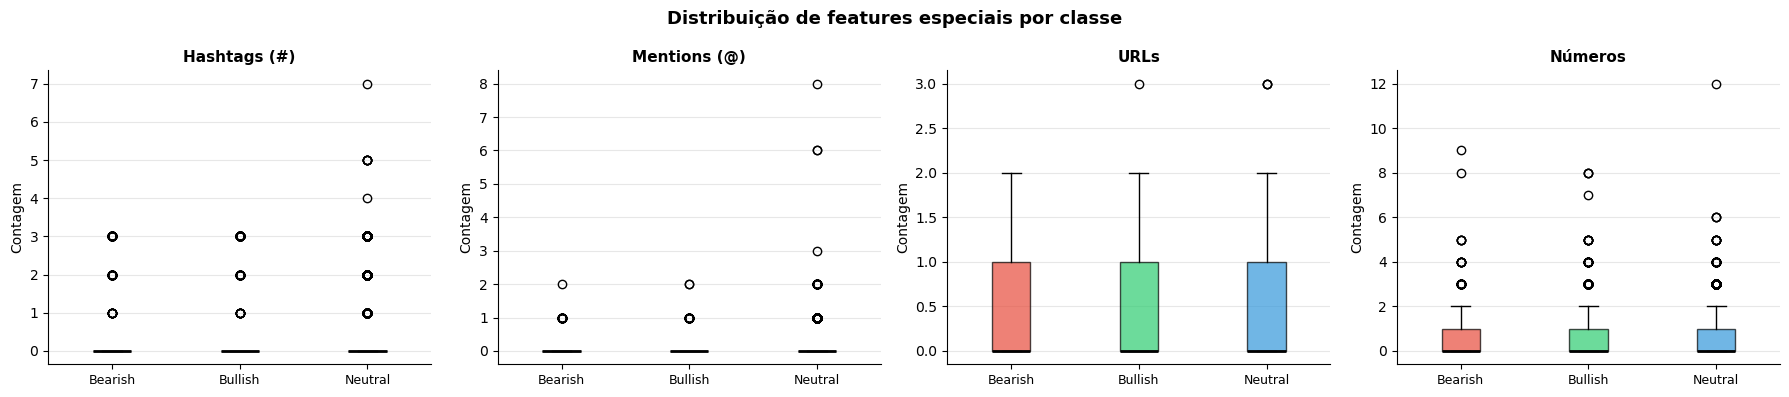

In [14]:
# ── Visualização das features especiais por classe ───────────────────────────
features  = ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']
feat_labels = ['Hashtags (#)', 'Mentions (@)', 'URLs', 'Números']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for feat, flabel, ax in zip(features, feat_labels, axes):
    data_by_class = [df[df['label'] == lbl][feat].values for lbl in [0,1,2]]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'], fontsize=9)
    ax.set_title(flabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Contagem')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Distribuição de features especiais por classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_special_features.png', bbox_inches='tight')
plt.show()

## 7. Top Hashtags e Cashtags

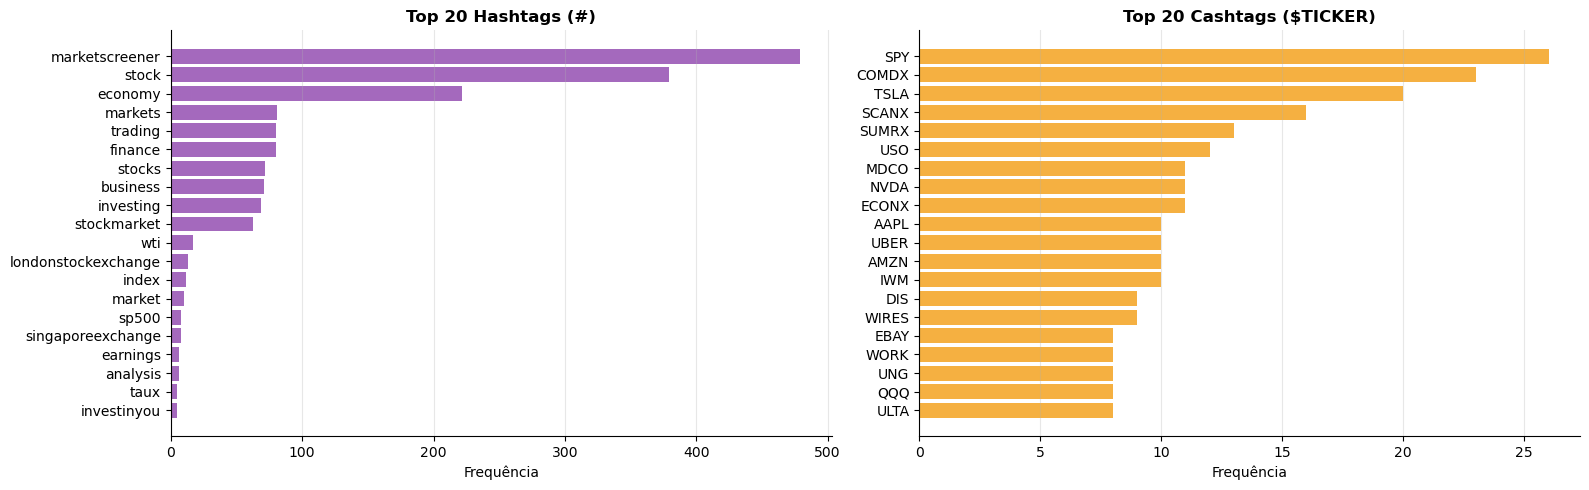

In [15]:
# ── Hashtags mais comuns ──────────────────────────────────────────────────────
all_hashtags = []
for txt in df['text']:
    all_hashtags.extend(re.findall(r'#(\w+)', str(txt).lower()))

top_hashtags = Counter(all_hashtags).most_common(20)

all_cashtags = []
for txt in df['text']:
    all_cashtags.extend(re.findall(r'\$([A-Z]{1,5})', str(txt)))
top_cashtags = Counter(all_cashtags).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if top_hashtags:
    words_h, counts_h = zip(*top_hashtags)
    axes[0].barh(list(reversed(words_h)), list(reversed(counts_h)),
                 color='#8e44ad', edgecolor='none', alpha=0.8)
    axes[0].set_title('Top 20 Hashtags (#)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Frequência')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

if top_cashtags:
    words_c, counts_c = zip(*top_cashtags)
    axes[1].barh(list(reversed(words_c)), list(reversed(counts_c)),
                 color='#f39c12', edgecolor='none', alpha=0.8)
    axes[1].set_title('Top 20 Cashtags ($TICKER)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequência')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
else:
    axes[1].text(0.5, 0.5, 'Sem cashtags encontrados', ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.savefig('fig_hashtags_cashtags.png', bbox_inches='tight')
plt.show()

## 8. Heatmap de Co-ocorrência das Top Palavras

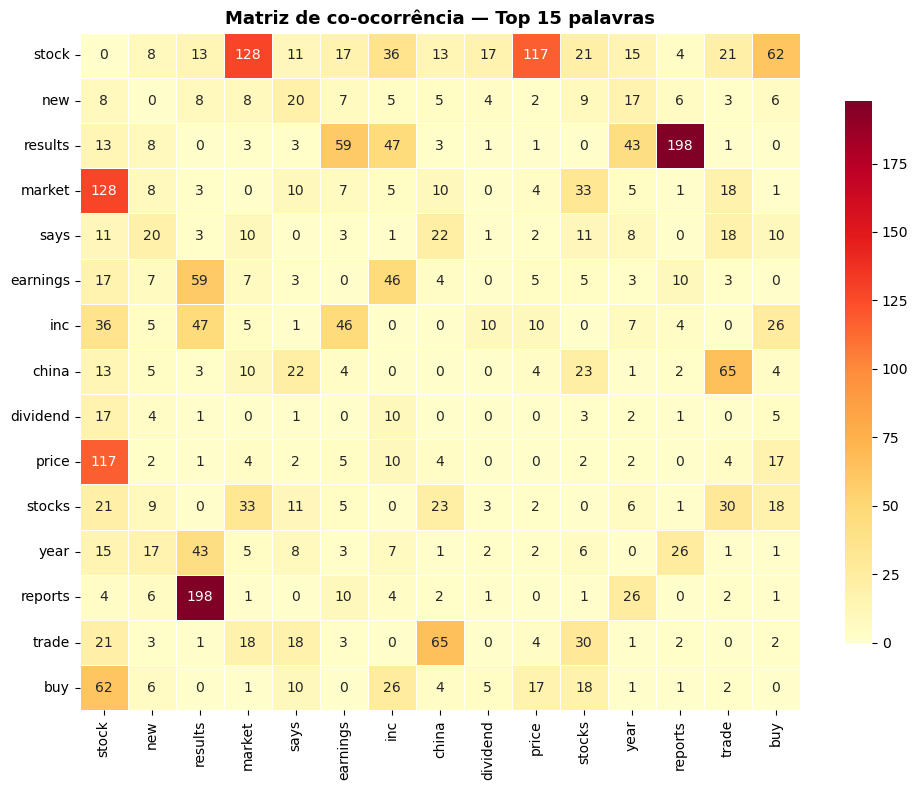

In [16]:
# ── Matriz de co-ocorrência (top 15 palavras) ─────────────────────────────────
from itertools import combinations

top_words_list = [w for w, _ in freq.most_common(15)]
cooc = pd.DataFrame(0, index=top_words_list, columns=top_words_list)

for txt in df['text']:
    tokens = set(tokenize_clean(txt)) & set(top_words_list)
    for w1, w2 in combinations(tokens, 2):
        cooc.loc[w1, w2] += 1
        cooc.loc[w2, w1] += 1

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de co-ocorrência — Top 15 palavras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cooccurrence.png', bbox_inches='tight')
plt.show()

## 9. Resumo e Conclusões

In [17]:
# ── Resumo final ──────────────────────────────────────────────────────────────
print('=' * 60)
print('RESUMO DA DATA EXPLORATION')
print('=' * 60)
print(f'Total de tweets (treino)         : {len(df):,}')
print(f'Vocabulário único (sem stopwords): {len(vocab):,} palavras')
print(f'Total de tokens                  : {len(all_tokens):,}')
print(f'Comprimento médio (palavras)     : {df["n_words"].mean():.1f}')
print(f'Comprimento médio (chars)        : {df["n_chars"].mean():.1f}')
print()
print('Distribuição das classes:')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
print()
print(f'Baseline majority class: {majority_acc:.1f}%')
print()
print('Top 5 palavras mais frequentes:')
for w, c in freq.most_common(5):
    print(f'  {w:<20} {c:>5}')
print('=' * 60)
print()
print('CONCLUSÕES PARA O RELATÓRIO:')
print('- O dataset está [VERIFICAR: balanceado / desbalanceado?].')
print('- Os tweets são curtos (média ~X palavras), típico de Twitter.')
print('- Presença de URLs, hashtags e cashtags exige preprocessing específico.')
print('- As word clouds mostram vocabulário distinto entre classes.')
print('- [ADICIONAR MAIS CONCLUSÕES APÓS VER OS RESULTADOS]')

RESUMO DA DATA EXPLORATION
Total de tweets (treino)         : 9,543
Vocabulário único (sem stopwords): 14,016 palavras
Total de tokens                  : 73,385
Comprimento médio (palavras)     : 12.2
Comprimento médio (chars)        : 85.8

Distribuição das classes:
  Bearish (0): 1,442 (15.1%)
  Bullish (1): 1,923 (20.2%)
  Neutral (2): 6,178 (64.7%)

Baseline majority class: 64.7%

Top 5 palavras mais frequentes:
  stock                  611
  new                    417
  results                374
  market                 359
  says                   349

CONCLUSÕES PARA O RELATÓRIO:
- O dataset está [VERIFICAR: balanceado / desbalanceado?].
- Os tweets são curtos (média ~X palavras), típico de Twitter.
- Presença de URLs, hashtags e cashtags exige preprocessing específico.
- As word clouds mostram vocabulário distinto entre classes.
- [ADICIONAR MAIS CONCLUSÕES APÓS VER OS RESULTADOS]
